# Permutation-Based Feature Importance

## Overview

Permutation importance measures how much model performance degrades when a feature's values are randomly shuffled, breaking its relationship with the response. A large drop in performance = the feature is important; no drop = the model doesn't rely on it.

**Algorithm:**
1. Compute baseline performance metric (RMSE, AUC, etc.) on test data
2. For each feature j:
   - Permute feature j (shuffle its values randomly)
   - Recompute performance on permuted data
   - Importance_j = baseline − permuted performance
3. Repeat K times; report mean ± SD

**Permutation importance vs. alternatives:**

| Method | Model-agnostic | Test-set | Handles correlations | Unbiased |
|---|---|---|---|---|
| Permutation | ✓ | ✓ | Partial | ✓ |
| SHAP mean \|SHAP\| | ✓ | ✓ | Better | ✓ |
| Gain (tree splits) | ✗ | ✗ | No | Biased |
| RF out-of-bag | ✗ | Approx | No | ✓ |

Key advantage: works with **any** model — linear, GAM, random forest, XGBoost, neural network.

---

## Setup

In [2]:
library(tidyverse)
library(ggplot2)
library(ranger)        # random forest
library(xgboost)
library(vip)           # vi_permute(), vip()
library(tidymodels)    # for model-agnostic wrapper
library(patchwork)

set.seed(42)

n <- 600
perm_data <- tibble(
  nitrate     = runif(n, 1, 10),
  water_qual  = runif(n, 2, 9),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  distance_km = rexp(n, 0.5),
  noise_1     = rnorm(n),   # truly uninformative
  noise_2     = rnorm(n),
  richness    = round(
    28 - 2.2*nitrate + 1.5*water_qual +
    0.015*elevation - 0.3*slope_pct - 0.8*distance_km +
    rnorm(n, 0, 3)
  )
)

feat_cols <- c("nitrate","water_qual","elevation",
               "slope_pct","distance_km","noise_1","noise_2")

# Train/test split
split    <- initial_split(perm_data, prop=0.75)
train_df <- training(split)
test_df  <- testing(split)

# Fit random forest
rf_fit <- ranger::ranger(
  richness ~ .,
  data      = train_df,
  num.trees = 500,
  importance= "permutation",  # built-in OOB permutation importance
  seed      = 42
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'xgboost' was built under R version 4.4.3"
Warning message:
"package 'vip' was built under R version 4.4.3"

---

## Permutation Importance with `vip`

# A tibble: 7 × 3
  Variable    Importance  StDev
  <chr>            <dbl>  <dbl>
1 nitrate       4.39     0.261 
2 water_qual    1.34     0.144 
3 elevation     0.268    0.0471
4 slope_pct     0.437    0.0679
5 distance_km   0.303    0.0750
6 noise_1       0.0119   0.0238
7 noise_2       0.000815 0.0212


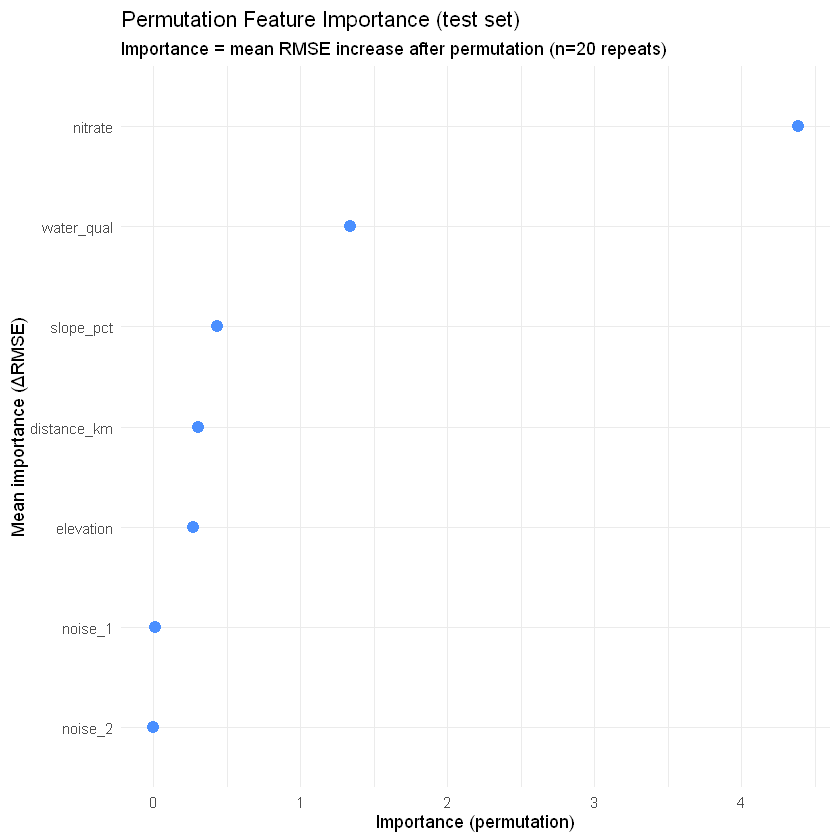

In [3]:
# vip::vi_permute: model-agnostic permutation importance on test set
# metric = "rmse": lower after permutation = important (metric is loss)
# nsim = 10: repeat permutation 10 times; report mean ± SD

pred_wrapper <- function(object, newdata) {
  predict(object, data=newdata)$predictions
}

perm_imp <- vip::vi_permute(
  object      = rf_fit,
  train       = test_df,          # use TEST set — not training data
  target      = "richness",
  metric      = "rmse",
  pred_wrapper= pred_wrapper,
  nsim        = 20,
  smaller_is_better = TRUE
)

print(perm_imp)

# Plot with uncertainty
vip::vip(
  perm_imp,
  num_features = 7,
  geom   = "point",
  include_type = TRUE,
  aesthetics = list(color="#4a8fff", fill="#4a8fff", size=3)
) +
  labs(title="Permutation Feature Importance (test set)",
       subtitle="Importance = mean RMSE increase after permutation (n=20 repeats)",
       x="Mean importance (ΔRMSE)") +
  theme_minimal()

---

## Importance with Confidence Intervals


Baseline RMSE: 4.008
# A tibble: 7 × 5
  feature     mean_imp sd_imp   ci_lo  ci_hi
  <chr>          <dbl>  <dbl>   <dbl>  <dbl>
1 nitrate       4.42   0.323   3.88   4.93  
2 water_qual    1.36   0.160   1.06   1.61  
3 slope_pct     0.427  0.0813  0.281  0.544 
4 distance_km   0.298  0.0574  0.173  0.390 
5 elevation     0.253  0.0641  0.120  0.337 
6 noise_2       0.0108 0.0202 -0.0305 0.0502
7 noise_1       0.0081 0.0237 -0.0425 0.0458


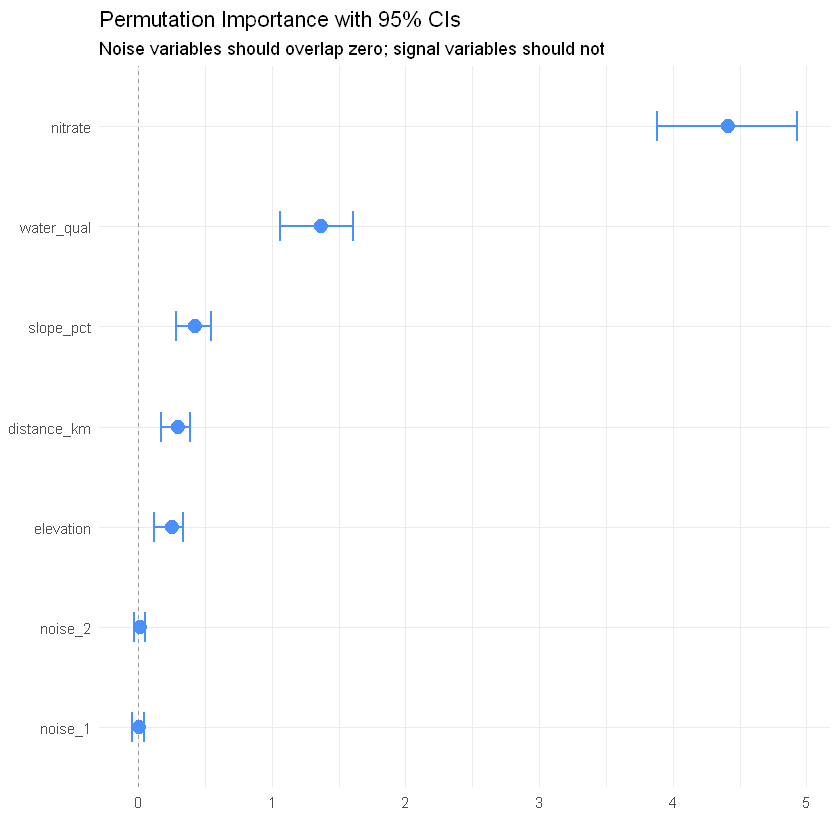

In [4]:
# Run permutation manually to get per-repetition values
# This reveals variance in importance estimates — critical for small test sets

baseline_rmse <- sqrt(mean((
  predict(rf_fit, data=test_df)$predictions - test_df$richness
)^2))

n_sim <- 30
imp_reps <- map_dfr(feat_cols, function(feat) {
  map_dbl(1:n_sim, function(i) {
    test_perm         <- test_df
    test_perm[[feat]] <- sample(test_perm[[feat]])
    preds_perm        <- predict(rf_fit, data=test_perm)$predictions
    sqrt(mean((preds_perm - test_df$richness)^2)) - baseline_rmse
  }) %>%
    tibble(importance=.) %>%
    mutate(feature=feat)
}) %>%
  group_by(feature) %>%
  summarise(
    mean_imp = mean(importance),
    sd_imp   = sd(importance),
    ci_lo    = quantile(importance, 0.025),
    ci_hi    = quantile(importance, 0.975)
  ) %>%
  arrange(desc(mean_imp))

ggplot(imp_reps,
       aes(x=fct_reorder(feature, mean_imp), y=mean_imp,
           ymin=ci_lo, ymax=ci_hi,
           color=mean_imp > 0)) +
  geom_hline(yintercept=0, linetype="dashed", color="gray60") +
  geom_errorbar(width=0.3, linewidth=0.8) +
  geom_point(size=3.5) +
  scale_color_manual(values=c("FALSE"="gray60","TRUE"="#4a8fff"),
                     guide="none") +
  coord_flip() +
  labs(title="Permutation Importance with 95% CIs",
       subtitle="Noise variables should overlap zero; signal variables should not",
       x=NULL, y="Mean ΔRMSE (permuted − baseline)") +
  theme_minimal()

cat(sprintf("\nBaseline RMSE: %.3f\n", baseline_rmse))
print(imp_reps %>% mutate(across(where(is.numeric), ~round(.x, 4))))

---

## Comparing Importance Across Models

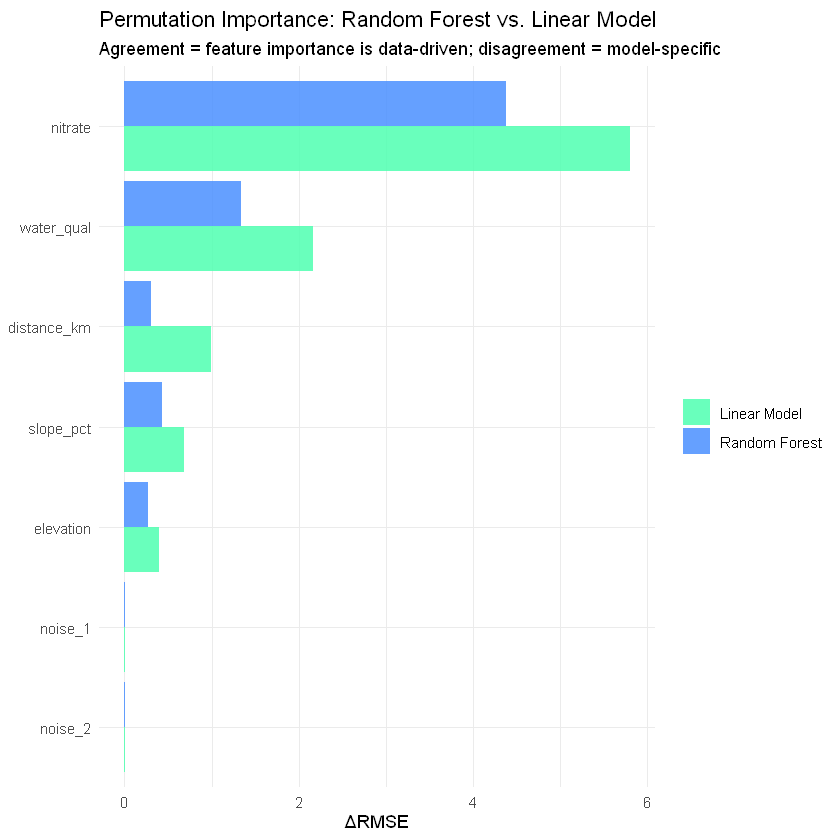

In [5]:
# Same test set; same metric; different model families
# Reveals whether feature importance is model-specific or data-driven

# Linear model
lm_fit <- lm(richness ~ ., data=train_df)
lm_pred_fn <- function(object, newdata) predict(object, newdata=newdata)

lm_imp <- vip::vi_permute(
  object=lm_fit, train=test_df, target="richness",
  metric="rmse", pred_wrapper=lm_pred_fn,
  nsim=20, smaller_is_better=TRUE
)

# Combine and compare
comparison_imp <- bind_rows(
  perm_imp %>% mutate(model="Random Forest"),
  lm_imp   %>% mutate(model="Linear Model")
)

ggplot(comparison_imp,
       aes(x=fct_reorder(Variable, Importance), y=Importance,
           fill=model)) +
  geom_col(position="dodge", alpha=0.85) +
  scale_fill_manual(values=c("Random Forest"="#4a8fff","Linear Model"="#4fffb0")) +
  coord_flip() +
  labs(title="Permutation Importance: Random Forest vs. Linear Model",
       subtitle="Agreement = feature importance is data-driven; disagreement = model-specific",
       x=NULL, y="ΔRMSE", fill=NULL) +
  theme_minimal()

---

## Common Pitfalls

**1. Computing permutation importance on training data**  
Training-set permutation importance is biased: it measures how much the model has memorised the training data, not how much the feature contributes to generalisation. Always permute on held-out test data. The difference between training and test importance rankings often reveals features the model has overfit.

**2. Using only one permutation repeat**  
Permutation importance has variance — different random shuffles give different RMSE changes. With only one repeat, you cannot distinguish a truly unimportant feature (importance near zero consistently) from a feature that happened to get a near-zero importance by chance. Use at least 10–20 repeats and report mean ± SD or 95% CIs.

**3. Over-interpreting importance of correlated features**  
When two features are highly correlated (e.g. nitrate and conductivity), permuting one may barely degrade performance because the model can compensate using the other. Permutation importance distributes importance arbitrarily between correlated features. Use SHAP or partial importance methods that condition on other features when collinearity is present.

**4. Comparing importance across models with different baseline performance**  
Importance is measured as ΔRMSE from baseline. If model A has baseline RMSE = 2.0 and model B has baseline RMSE = 5.0, identical ΔRMSE values represent very different relative importance. Normalise by baseline RMSE (ΔRMSE / baseline) for cross-model comparison.

**5. Reporting importance from built-in tree importance instead of permutation**  
Built-in random forest importance (mean decrease in impurity / Gini) is biased toward high-cardinality and continuous features, and is computed on training data. `ranger(importance='permutation')` uses OOB permutation which is better but still training-based. For publication, always use `vip::vi_permute()` on held-out test data.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*